# Full Pipeline — AF(d), PSD/β, ApEn, SampEn — Figures 6a, 6b, 7a, 7b

**Data:** `Chennel_Data.xlsx`, one sheet per year: 1990, 1995, 2000, 2005, 2010, 2016, 2020, 2025.
Each sheet has columns `SL_NO` and `distance` (radial distance in meters of each channel-crossing point from the river mouth).

**Workflow**
1. Load data, build raw AF(d) per year (count of crossings at each distance)
2. Fill any missing 5 km bins with 0 so the signal is evenly spaced (required for PSD/FFT)
3. Normalize d (d/R) and AF(d) (AF/total) — Section 3.3
4. **Figure 6a** — AF(d) vs distance, all years overlaid
5. Compute PSD via FFT, per year — Section 3.6
6. **Figure 6b** — PSD vs wave number, log–log, all years overlaid
7. Fit log–log slope → β per year
8. **Figure 7b** — β by year (bar chart)
9. Compute ApEn and SampEn per year (m=2, r=0.15×std) — Section 3.5
10. **Figure 7a** — ApEn and SampEn by year (bar chart)
11. Save everything to Excel

In [1]:
import numpy as np                 # numerical arrays, FFT, linear algebra
import pandas as pd                # reading Excel sheets, building tables
import matplotlib.pyplot as plt    # plotting Figures 6a, 6b, 7a, 7b
from scipy.stats import linregress # least-squares fit for the PSD log-log slope (beta)

---
## Step 1 — Load file and list year-sheets

In [6]:
FILE_PATH = r"G:\Cahnnel Complexity Ganges\Chennel_Data.xlsx"   # edit to your actual path

xls = pd.ExcelFile(FILE_PATH)          # open the workbook without loading all sheets yet
sheet_names = xls.sheet_names          # list of sheet names -> these are your years
print("Years found:", sheet_names)

Years found: ['1990', '1995', '2000', '2005', '2010', '2016', '2020', '2025']


---
## Step 2 — Build raw AF(d) per year, then fill gaps so the grid is uniform

PSD (FFT) requires an evenly-spaced signal. If a 5 km band happens to contain **zero** crossings, that distance value simply won't appear in the raw data — we must insert AF=0 for it explicitly, otherwise the spacing between samples becomes irregular.

In [7]:
DELTA_D = 5000   # bin spacing used when the circles were generated (5 km, in meters)

def build_af_vector(file_path, sheet_name, distance_col="distance"):
    df = pd.read_excel(file_path, sheet_name=sheet_name)      # read one year's sheet
    counts = df[distance_col].value_counts().sort_index()     # unique distance -> count, sorted ascending
    distances = counts.index.to_numpy()                       # array of distinct distances (raw, may have gaps)
    af_vector = counts.to_numpy()                              # matching channel counts
    return distances, af_vector

def fill_gaps(distances, af_vector, delta_d=DELTA_D):
    """Reindex onto a full evenly-spaced grid from min to max distance, filling missing bins with 0."""
    d_min, d_max = distances.min(), distances.max()                     # study-reach extent for this year
    full_grid = np.arange(d_min, d_max + delta_d, delta_d)              # complete 5 km grid, no gaps
    af_full = np.zeros(len(full_grid))                                  # start with all zeros
    idx_map = {d: i for i, d in enumerate(full_grid)}                   # lookup: distance value -> grid index
    for d, af in zip(distances, af_vector):                             # place actual counts into the grid
        af_full[idx_map[d]] = af
    return full_grid, af_full

d_data = {}     # year -> full distance grid (meters)
af_data = {}    # year -> full AF vector (raw counts, gap-filled)

for year in sheet_names:
    raw_d, raw_af = build_af_vector(FILE_PATH, year)     # step 1: raw unique-distance counts
    full_d, full_af = fill_gaps(raw_d, raw_af)           # step 2: fill any missing bins with 0
    d_data[year] = full_d
    af_data[year] = full_af
    print(f"Year {year}: N={len(full_af)} bins, AF = {full_af}")

Year 1990: N=41 bins, AF = [1. 2. 1. 1. 2. 2. 4. 2. 4. 3. 4. 2. 4. 4. 3. 2. 2. 3. 3. 3. 3. 3. 7. 1.
 5. 2. 1. 2. 2. 3. 3. 2. 2. 3. 2. 6. 4. 3. 3. 3. 1.]
Year 1995: N=41 bins, AF = [1. 1. 1. 1. 1. 1. 1. 3. 4. 2. 3. 3. 3. 4. 3. 3. 2. 3. 4. 3. 5. 5. 5. 2.
 4. 4. 1. 1. 2. 3. 3. 2. 2. 4. 2. 5. 4. 6. 3. 2. 1.]
Year 2000: N=41 bins, AF = [1. 1. 2. 1. 1. 1. 1. 3. 3. 2. 2. 3. 4. 3. 2. 2. 4. 4. 2. 2. 5. 5. 6. 2.
 3. 4. 1. 1. 2. 3. 6. 2. 2. 2. 1. 1. 5. 5. 3. 2. 2.]
Year 2005: N=41 bins, AF = [1. 2. 1. 1. 1. 2. 1. 3. 3. 3. 3. 3. 4. 3. 3. 2. 2. 4. 6. 3. 6. 4. 6. 1.
 2. 2. 2. 3. 2. 3. 3. 1. 2. 2. 1. 1. 5. 9. 4. 2. 1.]
Year 2010: N=41 bins, AF = [1. 2. 2. 2. 1. 1. 2. 2. 3. 4. 3. 3. 3. 3. 3. 3. 4. 2. 2. 4. 5. 5. 6. 2.
 2. 3. 2. 3. 2. 3. 3. 1. 2. 3. 1. 2. 9. 8. 5. 2. 1.]
Year 2016: N=41 bins, AF = [ 2.  2.  2.  1.  1.  2.  5.  2.  3.  4.  3.  3.  4.  3.  5.  2.  4.  2.
  5.  4.  4.  4.  5.  1.  2.  2.  3.  4.  3.  3.  4.  2.  2.  3.  1.  2.
  6. 10.  3.  4.  2.]
Year 2020: N=41 bins, AF = [2. 2. 3. 2. 

---
## Step 3 — Normalize d and AF(d)  (Section 3.3)

- `d_norm = d / R` → every year's distance axis runs 0 to 1, regardless of actual reach length
- `AF_norm = AF / sum(AF)` → turns AF(d) into a probability-like distribution, removing the effect of "how many total crossings" a year happened to have

In [4]:
def normalize_af(distances, af_vector):
    R = distances.max()              # max radial distance for this year -> normalizing constant for d
    total = af_vector.sum()          # total channel-crossing count -> normalizing constant for AF
    d_norm = distances / R           # distance axis rescaled to 0-1
    af_norm = af_vector / total      # AF axis rescaled so it sums to 1
    return d_norm, af_norm

d_norm_data = {}    # year -> normalized distance (0-1)
af_norm_data = {}   # year -> normalized AF (sums to 1)

for year in sheet_names:
    d_norm, af_norm = normalize_af(d_data[year], af_data[year])   # apply normalization
    d_norm_data[year] = d_norm
    af_norm_data[year] = af_norm

---
## Figure 6a — AF(d) vs distance from mouth, all years overlaid

Matches the paper's Figure 6a style: x-axis = distance from mouth (km), y-axis = number of channels AF(d). Raw (non-normalized) counts are used here since that's what the paper actually plots visually.

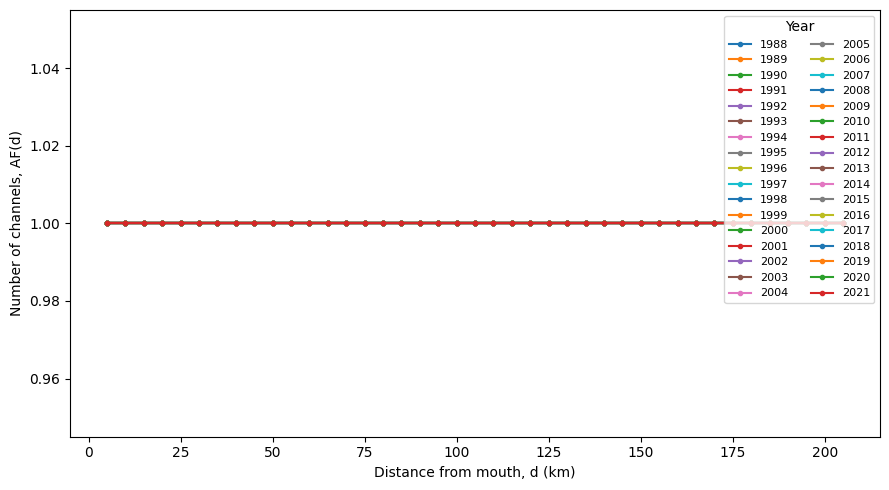

In [5]:
plt.figure(figsize=(9, 5))

for year in sheet_names:
    d_km = d_data[year] / 1000.0            # convert meters -> km for the x-axis, matching paper's Fig 6a
    plt.plot(d_km, af_data[year], marker='o', markersize=3, label=str(year))   # one line per year

plt.xlabel("Distance from mouth, d (km)")
plt.ylabel("Number of channels, AF(d)")
# plt.title("Anastomosing Function AF(d)")
plt.legend(title="Year", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

---
## Step 4 — Power Spectral Density (PSD) function  (Section 3.6, Eq. 14)

PSD decomposes the AF(d) signal into contributions at different spatial frequencies (wave numbers).
We use the **normalized** AF(d) signal so PSD magnitudes are comparable across years, same reasoning as for entropy.

In [7]:
def compute_psd(af_signal, delta_d_km):
    """
    af_signal   : 1D array, the (normalized) AF(d) values, evenly spaced
    delta_d_km  : spacing between samples in km (needed to get real spatial-frequency units)
    Returns wave numbers k (cycles/km) and PSD(k), keeping only positive frequencies (k>0).
    """
    N = len(af_signal)                                   # number of samples in this year's signal
    fft_vals = np.fft.rfft(af_signal)                     # real-input FFT -> only non-negative frequencies
    psd = np.abs(fft_vals) ** 2 / (2 * np.pi)              # |FFT|^2, scaled as in Eq. 14 of the paper
    k = np.fft.rfftfreq(N, d=delta_d_km)                   # wave number (cycles per km) for each FFT bin

    # drop k=0 (the DC / mean term) -- log(0) is undefined and it isn't a "fluctuation"
    k = k[1:]
    psd = psd[1:]
    return k, psd

---
## Step 5 — Compute PSD for every year

In [8]:
delta_d_km = DELTA_D / 1000.0     # bin spacing in km (5 km), used as the FFT sample spacing

psd_data = {}   # year -> (k array, PSD array)

for year in sheet_names:
    k_vals, psd_vals = compute_psd(af_norm_data[year], delta_d_km)   # FFT on the normalized AF signal
    psd_data[year] = (k_vals, psd_vals)
    print(f"Year {year}: k range = [{k_vals.min():.4f}, {k_vals.max():.4f}] cycles/km, "
          f"PSD range = [{psd_vals.min():.2e}, {psd_vals.max():.2e}]")

Year 1990: k range = [0.0049, 0.0976] cycles/km, PSD range = [2.62e-05, 4.33e-03]
Year 1995: k range = [0.0049, 0.0976] cycles/km, PSD range = [4.79e-06, 5.51e-03]
Year 2000: k range = [0.0049, 0.0976] cycles/km, PSD range = [2.92e-05, 3.67e-03]
Year 2005: k range = [0.0049, 0.0976] cycles/km, PSD range = [2.02e-05, 4.55e-03]
Year 2010: k range = [0.0049, 0.0976] cycles/km, PSD range = [2.31e-05, 5.52e-03]
Year 2016: k range = [0.0049, 0.0976] cycles/km, PSD range = [1.89e-04, 2.93e-03]
Year 2020: k range = [0.0049, 0.0976] cycles/km, PSD range = [2.45e-05, 3.11e-03]
Year 2025: k range = [0.0049, 0.0976] cycles/km, PSD range = [3.51e-05, 5.44e-03]


---
## Figure 6b — PSD vs wave number, log–log, all years overlaid

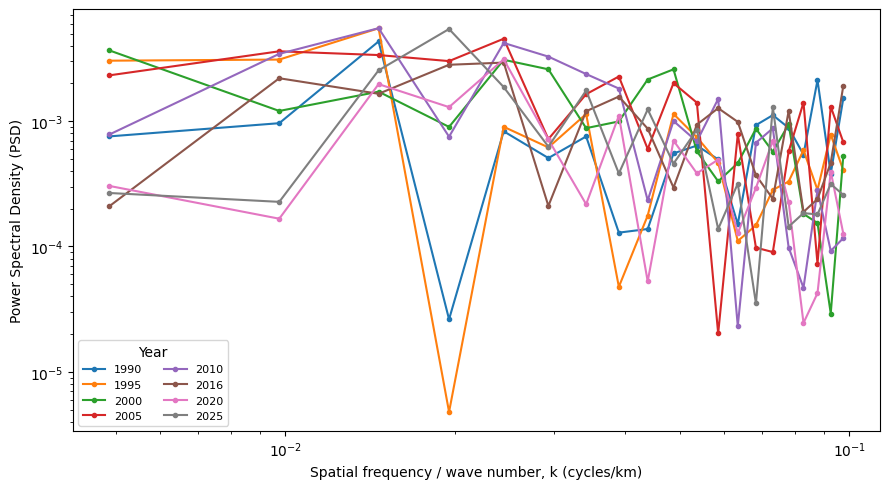

In [11]:
plt.figure(figsize=(9, 5))

for year in sheet_names:
    k_vals, psd_vals = psd_data[year]
    plt.plot(k_vals, psd_vals, marker='o', markersize=3, label=str(year))   # one PSD curve per year

plt.xscale('log')     # log-log axes, matching the paper's Figure 6b
plt.yscale('log')
plt.xlabel("Spatial frequency / wave number, k (cycles/km)")
plt.ylabel("Power Spectral Density (PSD)")
# plt.title("Figure 6b — PSD of AF(d) by Year (log–log)")
plt.legend(title="Year", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

---
## Step 6 — Fit log–log slope → β per year  (Eq. 15)

`PSD(k) ~ 1/k^β` → taking log of both sides gives `log(PSD) = -β * log(k) + const`, a straight line whose slope is `-β`. We fit this line by least squares and take `β = |slope|`.

In [12]:
beta_results = []

for year in sheet_names:
    k_vals, psd_vals = psd_data[year]
    log_k = np.log10(k_vals)          # log of wave number (x-axis for the regression)
    log_psd = np.log10(psd_vals)      # log of PSD (y-axis for the regression)

    slope, intercept, r_value, p_value, std_err = linregress(log_k, log_psd)   # least-squares line fit
    beta = abs(slope)                 # beta is the magnitude of the slope, per Eq. 15

    beta_results.append({"Year": year, "beta": beta, "R2": r_value**2, "p_value": p_value})
    print(f"Year {year}: slope={slope:.4f}, beta={beta:.4f}, R2={r_value**2:.3f}")

beta_df = pd.DataFrame(beta_results)
beta_df

Year 1990: slope=0.0329, beta=0.0329, R2=0.001
Year 1995: slope=-0.6208, beta=0.6208, R2=0.103
Year 2000: slope=-0.9256, beta=0.9256, R2=0.413
Year 2005: slope=-1.0112, beta=1.0112, R2=0.304
Year 2010: slope=-1.1683, beta=1.1683, R2=0.363
Year 2016: slope=-0.2351, beta=0.2351, R2=0.041
Year 2020: slope=-0.5805, beta=0.5805, R2=0.139
Year 2025: slope=-0.5160, beta=0.5160, R2=0.120


,Year,beta,R2,p_value
0,1990,0.032886,0.000567,0.920606
1,1995,0.620834,0.103250,0.167141
2,2000,0.925608,0.412783,0.002252
3,2005,1.011195,0.303656,0.011795
4,2010,1.168310,0.362618,0.004962
5,2016,0.235081,0.040725,0.393541
6,2020,0.580475,0.138858,0.105646
7,2025,0.515959,0.119814,0.134919


---
## Figure 7b — β (PSD slope) by year

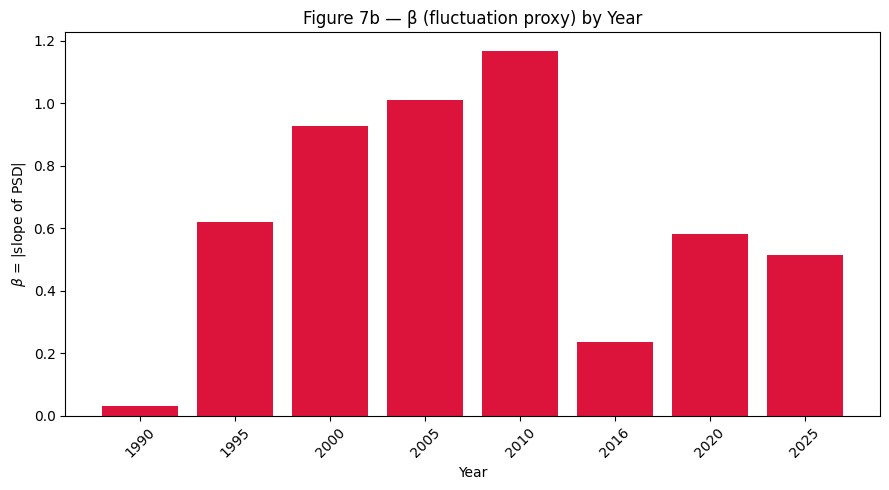

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(beta_df["Year"].astype(str), beta_df["beta"], color="crimson")   # one bar per year
plt.xlabel("Year")
plt.ylabel(r"$\beta$ = |slope of PSD|")
plt.title("Figure 7b — β (fluctuation proxy) by Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Step 7 — ApEn and SampEn functions  (Section 3.5, verified earlier against manual derivation)

In [14]:
def form_vectors(series, length):
    N = len(series)
    return np.array([series[i:i + length] for i in range(N - length + 1)])   # sliding windows of given length

def distance_matrix(vecs):
    n_vec = len(vecs)
    D = np.zeros((n_vec, n_vec))
    for i in range(n_vec):
        for j in range(n_vec):
            D[i, j] = np.max(np.abs(vecs[i] - vecs[j]))    # Chebyshev distance between vector i and j
    return D

def _phi(series, m, r):
    vecs = form_vectors(series, m)               # build length-m template vectors
    D = distance_matrix(vecs)                    # pairwise distances between templates
    C = np.sum(D <= r, axis=1) / len(vecs)        # Ci: fraction of templates within tolerance r (includes self)
    return np.mean(np.log(C))                    # phi^m = average of ln(Ci)

def approximate_entropy(series, m, r):
    series = np.asarray(series, dtype=float)
    return _phi(series, m, r) - _phi(series, m + 1, r)    # ApEn = phi^m - phi^(m+1)

def sample_entropy(series, m, r):
    series = np.asarray(series, dtype=float)

    def _count_matches(mlen):
        vecs = form_vectors(series, mlen)
        n_vec = len(vecs)
        count = 0
        for i in range(n_vec):
            for j in range(i + 1, n_vec):                 # only i<j pairs -> excludes self-match, no double count
                d = np.max(np.abs(vecs[i] - vecs[j]))
                if d <= r:
                    count += 1
        return count

    B = _count_matches(m)          # matches at template length m
    A = _count_matches(m + 1)      # matches at template length m+1

    if B == 0 or A == 0:
        return np.nan               # undefined if no matches found at this r
    return -np.log(A / B)           # SampEn = -ln(A/B)

---
## Step 8 — Compute ApEn and SampEn per year (m=2, r=0.15×std of normalized AF)

In [15]:
m_val = 2
entropy_results = []

for year in sheet_names:
    af_norm = af_norm_data[year]                 # use the normalized AF vector
    r_year = 0.15 * np.std(af_norm)              # tolerance scaled to this year's spread

    apen_val = approximate_entropy(af_norm, m_val, r_year)
    sampen_val = sample_entropy(af_norm, m_val, r_year)

    entropy_results.append({"Year": year, "r": r_year, "ApEn": apen_val, "SampEn": sampen_val})
    print(f"Year {year}: r={r_year:.5f}, ApEn={apen_val:.4f}, SampEn={sampen_val:.4f}")

entropy_df = pd.DataFrame(entropy_results)
entropy_df

Year 1990: r=0.00173, ApEn=0.5663, SampEn=1.2192
Year 1995: r=0.00183, ApEn=0.5267, SampEn=1.1239
Year 2000: r=0.00203, ApEn=0.6236, SampEn=1.7677
Year 2005: r=0.00227, ApEn=0.6546, SampEn=1.8718
Year 2010: r=0.00216, ApEn=0.6032, SampEn=1.4088
Year 2016: r=0.00191, ApEn=0.5205, SampEn=1.3863
Year 2020: r=0.00145, ApEn=0.6591, SampEn=1.3683
Year 2025: r=0.00177, ApEn=0.5304, SampEn=1.3863


,Year,r,ApEn,SampEn
0,1990,0.001729,0.566264,1.219240
1,1995,0.001826,0.526687,1.123930
2,2000,0.002027,0.623596,1.767662
3,2005,0.002267,0.654556,1.871802
4,2010,0.002163,0.603150,1.408767
5,2016,0.001914,0.520466,1.386294
6,2020,0.001448,0.659056,1.368276
7,2025,0.001765,0.530403,1.386294


---
## Figure 7a — ApEn and SampEn by year (dual-axis bar chart)

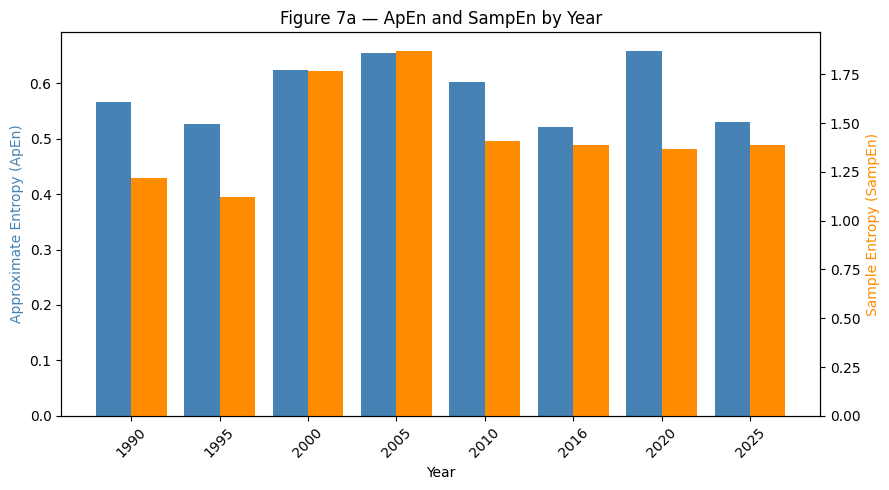

In [16]:
fig, ax1 = plt.subplots(figsize=(9, 5))

x_pos = np.arange(len(entropy_df))     # bar positions, one per year
width = 0.4                             # bar width so ApEn/SampEn bars sit side by side

ax1.bar(x_pos - width/2, entropy_df["ApEn"], width=width, color="steelblue", label="ApEn")
ax1.set_ylabel("Approximate Entropy (ApEn)", color="steelblue")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(entropy_df["Year"].astype(str), rotation=45)

ax2 = ax1.twinx()                       # second y-axis sharing the same x-axis
ax2.bar(x_pos + width/2, entropy_df["SampEn"], width=width, color="darkorange", label="SampEn")
ax2.set_ylabel("Sample Entropy (SampEn)", color="darkorange")

ax1.set_xlabel("Year")
ax1.set_title("Figure 7a — ApEn and SampEn by Year")
fig.tight_layout()
plt.show()

---
## Step 9 — Combine and save all results

In [17]:
final_df = entropy_df.merge(beta_df[["Year", "beta", "R2"]], on="Year")   # combine entropy + beta tables
print(final_df)

OUTPUT_PATH = r"G:\Cahnnel Complexity Ganges\AF_Full_Results.xlsx"
final_df.to_excel(OUTPUT_PATH, index=False)         # save the combined results table
print(f"\nSaved combined results to: {OUTPUT_PATH}")

   Year         r      ApEn    SampEn      beta        R2
0  1990  0.001729  0.566264  1.219240  0.032886  0.000567
1  1995  0.001826  0.526687  1.123930  0.620834  0.103250
2  2000  0.002027  0.623596  1.767662  0.925608  0.412783
3  2005  0.002267  0.654556  1.871802  1.011195  0.303656
4  2010  0.002163  0.603150  1.408767  1.168310  0.362618
5  2016  0.001914  0.520466  1.386294  0.235081  0.040725
6  2020  0.001448  0.659056  1.368276  0.580475  0.138858
7  2025  0.001765  0.530403  1.386294  0.515959  0.119814

Saved combined results to: G:\Cahnnel Complexity Ganges\AF_Full_Results.xlsx
